#### Correlation Analysis

In [1]:
import numpy as np
import torch

# ----------------------------
# 0) Load dataset and build size_dict from x (no .num_nodes required)
# ----------------------------
DATA_PATH = "gnn_structural_netlist_dataset.pt"  # update if needed

obj = torch.load(DATA_PATH, map_location="cpu")
data_list = obj["data_list"]

# circuit_name -> num_nodes
size_dict = {}
for d in data_list:
    cname = d.circuit_name
    n_nodes = int(d.x.size(0))  # THIS is the node count
    size_dict[cname] = n_nodes

print(f"[INFO] Loaded {len(data_list)} circuits from {DATA_PATH}")
print("[INFO] Example sizes:", list(size_dict.items())[:5])


# ----------------------------
# 1) Your per-circuit Spearman values (GNN only) - from plotting code
# ----------------------------

# Seed 0
seed0_circuits = ["c1355.v", "c432.v", "Priority.v", "square.v", "cavlc.v", "log2.v"]
gcn_seed0 = [-0.085, -0.549,  0.315,  0.077,  0.189,  0.415]
gat_seed0 = [ 0.020, -0.563, -0.615, -0.581, -0.662,  0.264]
gin_seed0 = [-0.156, -0.412, -0.585, -0.377,  0.293,  0.008]

# Seed 1
seed1_circuits = ["c499.v", "square.v", "sqrt.v", "log2.v", "c7552.v", "c880.v"]
gcn_seed1 = [ 0.154, -0.141,  0.239,  0.411,  0.254,  0.216]
gat_seed1 = [ 0.298,  0.255,  0.437,  0.119,  0.103,  0.165]
gin_seed1 = [ 0.286, -0.613, -0.523,  0.020,  0.190, -0.175]


# ----------------------------
# 2) Helper functions
# ----------------------------
def corrcoef_safe(a, b):
    a = np.asarray(a, dtype=float).flatten()
    b = np.asarray(b, dtype=float).flatten()
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def infer_family(name):
    """
    Heuristic:
      - ISCAS: c<number>.v (e.g., c432.v, c7552.v)
      - EPFL/others: everything else (Priority.v, square.v, log2.v, sqrt.v, cavlc.v, ...)
    """
    base = name.lower()
    if base.startswith("c"):
        token = base[1:].split(".")[0]
        if token.isdigit():
            return "ISCAS"
    return "EPFL"

def summarize_by_family(circuits, spearman_vals):
    fam = [infer_family(c) for c in circuits]
    sp = np.asarray(spearman_vals, dtype=float)

    iscas = sp[np.array([f == "ISCAS" for f in fam])]
    epfl  = sp[np.array([f == "EPFL"  for f in fam])]

    return {
        "ISCAS_n": int(len(iscas)),
        "ISCAS_mean": float(np.mean(iscas)) if len(iscas) else np.nan,
        "ISCAS_std": float(np.std(iscas)) if len(iscas) else np.nan,
        "EPFL_n": int(len(epfl)),
        "EPFL_mean": float(np.mean(epfl)) if len(epfl) else np.nan,
        "EPFL_std": float(np.std(epfl)) if len(epfl) else np.nan,
        "ALL_mean": float(np.mean(sp)) if len(sp) else np.nan,
        "ALL_std": float(np.std(sp)) if len(sp) else np.nan,
    }

def size_stats(circuits, spearman_vals, size_dict):
    sp = np.asarray(spearman_vals, dtype=float)
    sizes = np.asarray([size_dict.get(c, np.nan) for c in circuits], dtype=float)

    # sanity: any missing sizes?
    missing = [c for c in circuits if c not in size_dict]
    if missing:
        print("[WARN] Missing sizes for circuits:", missing)

    unweighted = float(np.mean(sp))
    weighted = float(np.average(sp, weights=sizes)) if np.all(np.isfinite(sizes)) else np.nan
    size_corr = corrcoef_safe(sizes, sp) if np.all(np.isfinite(sizes)) else np.nan

    return {
        "sizes": sizes,
        "unweighted_mean": unweighted,
        "weighted_mean": weighted,
        "delta": (weighted - unweighted) if np.isfinite(weighted) else np.nan,
        "corr_size_spearman": size_corr,
    }

def report(seed_name, circuits, model_dict, size_dict):
    print("\n" + "="*72)
    print(seed_name)
    print("="*72)

    sizes = [size_dict.get(c, None) for c in circuits]
    fams  = [infer_family(c) for c in circuits]
    print("Circuits :", circuits)
    print("Family   :", fams)
    print("Size(|V|):", sizes)

    for model, sp in model_dict.items():
        print(f"\n--- {model} ---")
        sp = list(sp)

        fam = summarize_by_family(circuits, sp)
        ss  = size_stats(circuits, sp, size_dict)

        print("Family-wise Spearman:")
        print(f"  ISCAS: n={fam['ISCAS_n']}, mean={fam['ISCAS_mean']:+.4f}, std={fam['ISCAS_std']:.4f}")
        print(f"  EPFL : n={fam['EPFL_n']},  mean={fam['EPFL_mean']:+.4f}, std={fam['EPFL_std']:.4f}")
        print(f"  ALL  : mean={fam['ALL_mean']:+.4f}, std={fam['ALL_std']:.4f}")

        print("Size sensitivity:")
        print(f"  Corr(|V|, Spearman) = {ss['corr_size_spearman']:+.4f}")

        print("Large-circuit dominance check:")
        print(f"  Unweighted mean Spearman      = {ss['unweighted_mean']:+.4f}")
        print(f"  Size-weighted mean Spearman   = {ss['weighted_mean']:+.4f}")
        print(f"  Delta (weighted - unweighted) = {ss['delta']:+.4f}")


# ----------------------------
# 3) Run reports (Seed 0, Seed 1, pooled)
# ----------------------------
report(
    "SEED 0",
    seed0_circuits,
    {"GCN": gcn_seed0, "GAT": gat_seed0, "GIN": gin_seed0},
    size_dict
)

report(
    "SEED 1",
    seed1_circuits,
    {"GCN": gcn_seed1, "GAT": gat_seed1, "GIN": gin_seed1},
    size_dict
)

# pooled across 12 circuits
all_circuits = seed0_circuits + seed1_circuits
report(
    "POOLED (Seed 0 + Seed 1)",
    all_circuits,
    {"GCN": gcn_seed0 + gcn_seed1, "GAT": gat_seed0 + gat_seed1, "GIN": gin_seed0 + gin_seed1},
    size_dict
)

/tmp/ipykernel_124603/3459746729.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(DATA_PATH, map_location="cpu")
/home/rrk307/anaconda3/envs/gnn_circuits

[INFO] Loaded 30 circuits from gnn_structural_netlist_dataset.pt
[INFO] Example sizes: [('c17.v', 13), ('c432.v', 211), ('c499.v', 247), ('ctrl.v', 338), ('c880.v', 407)]

SEED 0
Circuits : ['c1355.v', 'c432.v', 'Priority.v', 'square.v', 'cavlc.v', 'log2.v']
Family   : ['ISCAS', 'ISCAS', 'EPFL', 'EPFL', 'EPFL', 'EPFL']
Size(|V|): [591, 211, 1951, 35454, 1262, 46810]

--- GCN ---
Family-wise Spearman:
  ISCAS: n=2, mean=-0.3170, std=0.2320
  EPFL : n=4,  mean=+0.2490, std=0.1276
  ALL  : mean=+0.0603, std=0.3162
Size sensitivity:
  Corr(|V|, Spearman) = +0.4840
Large-circuit dominance check:
  Unweighted mean Spearman      = +0.0603
  Size-weighted mean Spearman   = +0.2648
  Delta (weighted - unweighted) = +0.2044

--- GAT ---
Family-wise Spearman:
  ISCAS: n=2, mean=-0.2715, std=0.2915
  EPFL : n=4,  mean=-0.3985, std=0.3836
  ALL  : mean=-0.3562, std=0.3605
Size sensitivity:
  Corr(|V|, Spearman) = +0.4897
Large-circuit dominance check:
  Unweighted mean Spearman      = -0.3562
  Siz

#### Abalation Results

In [2]:
# CELL: Ablation study for M(v) components (no simulation)
# - Computes M_cent, M_core, M_sym per node using only topology
# - Builds full M and ablations: w/o symmetry, w/o core, w/o centrality
# - Trains a representative GCN and reports performance changes

import random
import numpy as np
import torch
from torch import nn
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader
import networkx as nx

# ----------------------------
# 0) Load dataset
# ----------------------------
DATA_PATH = "gnn_structural_netlist_dataset.pt"  # adjust if needed
obj = torch.load(DATA_PATH, map_location="cpu")
data_list = obj["data_list"]

print(f"[INFO] Loaded {len(data_list)} circuits from {DATA_PATH}")

# ----------------------------
# 1) Utilities
# ----------------------------
def minmax_norm(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    mn, mx = float(np.min(x)), float(np.max(x))
    if abs(mx - mn) < eps:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)

def zscore_per_circuit(y, mask=None, eps=1e-12):
    y = y.clone().float()
    if mask is None:
        vals = y
    else:
        vals = y[mask]
    mu = vals.mean()
    std = vals.std(unbiased=False)
    if std.item() < eps:
        std = torch.tensor(1.0, device=y.device)
    y_norm = (y - mu) / std
    return y_norm, mu, std

def spearmanr_np(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size < 2:
        return np.nan

    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a))
        return ranks

    r1 = rankdata(y_true)
    r2 = rankdata(y_pred)
    r1 -= r1.mean()
    r2 -= r2.mean()
    den = np.sqrt(np.sum(r1**2) * np.sum(r2**2))
    if den == 0:
        return np.nan
    return float(np.sum(r1 * r2) / den)

# ----------------------------
# 2) Compute component terms from topology only
# ----------------------------
# Definitions (all mapped to [0,1], higher => more "manipulable"):
#   M_cent = 1 - betweenness_norm      (backbone nodes less manipulable)
#   M_core = 1 - kcore_norm            (dense core less manipulable)
#   M_sym  = clustering_coeff_norm     (local symmetry proxy)
#
# Composite:
#   M = w_cent*M_cent + w_core*M_core + w_sym*M_sym

W = {"cent": 1.0, "core": 1.0, "sym": 1.0}  # equal weights by default

print("[INFO] Computing structural components per circuit (approx betweenness)...")
for d in data_list:
    # Build undirected NX graph from edge_index
    n = int(d.x.size(0))
    G = nx.Graph()
    G.add_nodes_from(range(n))
    ei = d.edge_index.cpu().numpy()
    for u, v in ei.T:
        G.add_edge(int(u), int(v))

    # ---- betweenness (approx for speed) ----
    if n < 3:
        bc = {i: 0.0 for i in range(n)}
    else:
        k = min(128, n)  # sampling for speed
        try:
            bc = nx.betweenness_centrality(G, normalized=True, k=k)
        except ZeroDivisionError:
            bc = {i: 0.0 for i in range(n)}
    bc_vec = np.array([bc.get(i, 0.0) for i in range(n)], dtype=np.float32)
    bc_norm = minmax_norm(bc_vec)
    m_cent = 1.0 - bc_norm

    # ---- k-core index ----
    try:
        core_num = nx.core_number(G)  # dict node->k
        core_vec = np.array([core_num.get(i, 0) for i in range(n)], dtype=np.float32)
    except Exception:
        core_vec = np.zeros(n, dtype=np.float32)
    core_norm = minmax_norm(core_vec)
    m_core = 1.0 - core_norm

    # ---- clustering coefficient ----
    try:
        cc = nx.clustering(G)  # dict node->clustering
        cc_vec = np.array([cc.get(i, 0.0) for i in range(n)], dtype=np.float32)
    except Exception:
        cc_vec = np.zeros(n, dtype=np.float32)
    m_sym = minmax_norm(cc_vec)

    # store component tensors
    d.m_cent = torch.from_numpy(m_cent).view(-1, 1)
    d.m_core = torch.from_numpy(m_core).view(-1, 1)
    d.m_sym  = torch.from_numpy(m_sym ).view(-1, 1)

print("[INFO] Component computation complete.")

# ----------------------------
# 3) Build full M(v) and ablated targets
# ----------------------------
def build_target(d, use_cent=True, use_core=True, use_sym=True, W=W):
    w_cent = W["cent"] if use_cent else 0.0
    w_core = W["core"] if use_core else 0.0
    w_sym  = W["sym"]  if use_sym  else 0.0
    denom = w_cent + w_core + w_sym
    if denom == 0:
        raise ValueError("All components disabled. Invalid ablation.")
    # renormalize weights so scale is comparable
    w_cent, w_core, w_sym = w_cent/denom, w_core/denom, w_sym/denom
    y = w_cent*d.m_cent + w_core*d.m_core + w_sym*d.m_sym
    return y  # shape [N,1]

# create y variants and per-circuit normalization (gate nodes only)
print("[INFO] Building full and ablated targets + per-circuit normalization...")
variants = {
    "Full":        dict(use_cent=True,  use_core=True,  use_sym=True),
    "-Symmetry":   dict(use_cent=True,  use_core=True,  use_sym=False),
    "-Core":       dict(use_cent=True,  use_core=False, use_sym=True),
    "-Centrality": dict(use_cent=False, use_core=True,  use_sym=True),
}

for d in data_list:
    gate_mask = d.gate_mask.bool()
    for name, cfg in variants.items():
        y = build_target(d, **cfg)              # [N,1]
        y_norm, mu, std = zscore_per_circuit(y, mask=gate_mask)

        setattr(d, f"y_{name}", y)
        setattr(d, f"y_{name}_norm", y_norm)
        setattr(d, f"y_{name}_mean", mu)
        setattr(d, f"y_{name}_std", std)

print("[INFO] Targets ready.")

# ----------------------------
# 4) GCN model (representative)
# ----------------------------
class GCNRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        h = x
        for conv in self.convs:
            h = self.act(conv(h, edge_index))
        return self.out(h)

# ----------------------------
# 5) Train/test by circuit and evaluate each ablation
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
in_dim = int(data_list[0].x.size(-1))
print(f"[INFO] Using device: {device} | in_dim={in_dim}")

seeds = [0, 1]       # match your current protocol
num_epochs = 10      # keep fast; increase later if needed
batch_size = 4
lr = 1e-3

def run_one(seed, target_name):
    # split by circuit
    idx = list(range(len(data_list)))
    rnd = random.Random(seed)
    rnd.shuffle(idx)
    split = int(0.8 * len(idx))
    tr_idx, te_idx = idx[:split], idx[split:]

    train_set = [data_list[i] for i in tr_idx]
    test_set  = [data_list[i] for i in te_idx]
    loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

    model = GCNRegressor(in_dim, hidden_dim=64, num_layers=3).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # train on normalized target
    for ep in range(1, num_epochs + 1):
        model.train()
        tot_loss, tot_g = 0.0, 0
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index)  # [N,1]
            gm = batch.gate_mask.bool()

            y_norm = getattr(batch, f"y_{target_name}_norm")
            pred_g = pred[gm]
            y_g    = y_norm[gm]
            if pred_g.numel() == 0:
                continue

            loss = loss_fn(pred_g, y_g)
            opt.zero_grad()
            loss.backward()
            opt.step()

            ng = int(gm.sum().item())
            tot_loss += float(loss.item()) * ng
            tot_g += ng

    # eval on original scale
    model.eval()
    all_true, all_pred = [], []

    with torch.no_grad():
        for d in test_set:
            dd = d.to(device)
            pred_norm = model(dd.x, dd.edge_index)  # [N,1]

            mu = getattr(dd, f"y_{target_name}_mean")
            std = getattr(dd, f"y_{target_name}_std")
            pred = (pred_norm * std + mu).cpu().numpy().flatten()

            y_true = getattr(dd, f"y_{target_name}").cpu().numpy().flatten()
            gm = dd.gate_mask.bool().cpu().numpy().astype(bool)

            all_true.append(y_true[gm])
            all_pred.append(pred[gm])

    yT = np.concatenate(all_true)
    yP = np.concatenate(all_pred)

    mse = float(np.mean((yT - yP) ** 2))
    mae = float(np.mean(np.abs(yT - yP)))
    spr = float(spearmanr_np(yT, yP))
    return mse, mae, spr

# run ablation grid
results = {name: [] for name in variants.keys()}

print("[INFO] Running GCN ablation experiments...")
for name in variants.keys():
    for seed in seeds:
        mse, mae, spr = run_one(seed, name)
        results[name].append((mse, mae, spr))
        print(f"  [{name:11s}] seed={seed} | MSE={mse:.6f} MAE={mae:.6f} Spr={spr:.4f}")

# summarize mean±std
def mean_std(arr, j):
    vals = [x[j] for x in arr]
    return float(np.mean(vals)), float(np.std(vals))

summary = {}
for name, arr in results.items():
    mse_m, mse_s = mean_std(arr, 0)
    mae_m, mae_s = mean_std(arr, 1)
    spr_m, spr_s = mean_std(arr, 2)
    summary[name] = (mse_m, mse_s, mae_m, mae_s, spr_m, spr_s)

# print as a compact table
print("\n================= ABLATION SUMMARY (GCN, mean ± std over seeds) =================")
print(f"{'Variant':12s} | {'MSE':>18s} | {'MAE':>18s} | {'Spearman':>18s}")
print("-"*80)
for name in ["Full", "-Symmetry", "-Core", "-Centrality"]:
    mse_m, mse_s, mae_m, mae_s, spr_m, spr_s = summary[name]
    print(f"{name:12s} | {mse_m:.6f} ± {mse_s:.6f} | {mae_m:.6f} ± {mae_s:.6f} | {spr_m:.4f} ± {spr_s:.4f}")

# compute drop relative to Full (use means)
full = summary["Full"]
print("\n================= PERFORMANCE DROP RELATIVE TO FULL (means only) =================")
for name in ["-Symmetry", "-Core", "-Centrality"]:
    mse_m, _, mae_m, _, spr_m, _ = summary[name]
    mseF, _, maeF, _, sprF, _ = full
    print(f"{name:12s} | ?MSE={mse_m-mseF:+.6f} | ?MAE={mae_m-maeF:+.6f} | ?Spr={spr_m-sprF:+.4f}")

/tmp/ipykernel_124603/1755667202.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(DATA_PATH, map_location="cpu")


[INFO] Loaded 30 circuits from gnn_structural_netlist_dataset.pt
[INFO] Computing structural components per circuit (approx betweenness)...
[INFO] Component computation complete.
[INFO] Building full and ablated targets + per-circuit normalization...
[INFO] Targets ready.
[INFO] Using device: cpu | in_dim=10
[INFO] Running GCN ablation experiments...
  [Full       ] seed=0 | MSE=0.001571 MAE=0.023654 Spr=0.8049
  [Full       ] seed=1 | MSE=0.001001 MAE=0.016197 Spr=0.8161
  [-Symmetry  ] seed=0 | MSE=0.003619 MAE=0.036770 Spr=0.8089
  [-Symmetry  ] seed=1 | MSE=0.002605 MAE=0.026852 Spr=0.8102
  [-Core      ] seed=0 | MSE=0.000428 MAE=0.004323 Spr=0.4419
  [-Core      ] seed=1 | MSE=0.000076 MAE=0.002645 Spr=0.6657
  [-Centrality] seed=0 | MSE=0.023618 MAE=0.108620 Spr=0.6759
  [-Centrality] seed=1 | MSE=0.019018 MAE=0.081219 Spr=0.7046

================= ABLATION SUMMARY (GCN, mean ± std over seeds) =================
Variant      |                MSE |                MAE |           S

#### Correlation Between Model Performance and Circuit Statistics

In [4]:
# CELL: Compute per-circuit Spearman for ALL circuits (fast)

import torch
import numpy as np
from torch import nn
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader

# ----------------------------
# 1) Load dataset
# ----------------------------
DATA_PATH = "gnn_structural_netlist_dataset.pt"
obj = torch.load(DATA_PATH, map_location="cpu")
data_list = obj["data_list"]

device = "cuda" if torch.cuda.is_available() else "cpu"
in_dim = data_list[0].x.size(-1)

# ----------------------------
# 2) Use existing y (Full M(v)) if stored
#    Otherwise assume d.y exists from earlier experiment
# ----------------------------

# Normalize per circuit (gate nodes)
for d in data_list:
    gate_mask = d.gate_mask.bool()
    y = d.y
    mu = y[gate_mask].mean()
    std = y[gate_mask].std()
    if std < 1e-6:
        std = torch.tensor(1.0)
    d.y_norm = (y - mu) / std
    d.y_mean = mu
    d.y_std = std

# ----------------------------
# 3) Simple GCN
# ----------------------------
class GCNRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        h = x
        for conv in self.convs:
            h = self.act(conv(h, edge_index))
        return self.out(h)

model = GCNRegressor(in_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loader = DataLoader(data_list, batch_size=4, shuffle=True)

# ----------------------------
# 4) Train briefly (10 epochs)
# ----------------------------
for epoch in range(10):
    model.train()
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index)
        gm = batch.gate_mask.bool()
        loss = loss_fn(pred[gm], batch.y_norm[gm])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("[INFO] Training complete.")

# ----------------------------
# 5) Compute per-circuit Spearman for ALL circuits
# ----------------------------
def spearmanr_np(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if len(y_true) < 2:
        return np.nan
    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a))
        return ranks
    r1 = rankdata(y_true)
    r2 = rankdata(y_pred)
    r1 -= r1.mean()
    r2 -= r2.mean()
    return float(np.sum(r1*r2)/np.sqrt(np.sum(r1**2)*np.sum(r2**2)))

spearman_all = {}
model.eval()
with torch.no_grad():
    for d in data_list:
        dd = d.to(device)
        pred_norm = model(dd.x, dd.edge_index)
        pred = (pred_norm * dd.y_std + dd.y_mean).cpu().numpy().flatten()
        y_true = dd.y.cpu().numpy().flatten()
        gm = dd.gate_mask.bool().cpu().numpy()
        spearman_all[d.circuit_name] = spearmanr_np(y_true[gm], pred[gm])

print("\n[INFO] Per-circuit Spearman computed for", len(spearman_all), "circuits.")

/tmp/ipykernel_121240/4273112868.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(DATA_PATH, map_location="cpu")


[INFO] Training complete.

[INFO] Per-circuit Spearman computed for 30 circuits.


In [5]:
# Compute statistics for all circuits (using existing size_dict etc.)

size_arr = []
edge_arr = []
fanin_arr = []
fanout_arr = []
spr_arr = []

for d in data_list:
    cname = d.circuit_name
    spr = spearman_all[cname]

    n = d.x.size(0)
    E = d.edge_index.size(1)

    src = d.edge_index[0]
    dst = d.edge_index[1]
    fanin = torch.bincount(dst, minlength=n).float().mean().item()
    fanout = torch.bincount(src, minlength=n).float().mean().item()

    size_arr.append(n)
    edge_arr.append(E)
    fanin_arr.append(fanin)
    fanout_arr.append(fanout)
    spr_arr.append(spr)

size_arr = np.array(size_arr)
edge_arr = np.array(edge_arr)
fanin_arr = np.array(fanin_arr)
fanout_arr = np.array(fanout_arr)
spr_arr = np.array(spr_arr)

def corr(x, y):
    return float(np.corrcoef(x, y)[0,1])

print("\n================ Correlation Across ALL Circuits (30) ================")
print(f"Corr(|V|, Spearman)  = {corr(size_arr, spr_arr):+.3f}")
print(f"Corr(|E|, Spearman)  = {corr(edge_arr, spr_arr):+.3f}")
print(f"Corr(FanIn, Spearman)= {corr(fanin_arr, spr_arr):+.3f}")
print(f"Corr(FanOut, Spearman)= {corr(fanout_arr, spr_arr):+.3f}")


================ Correlation Across ALL Circuits (30) ================
Corr(|V|, Spearman)  = -0.166
Corr(|E|, Spearman)  = -0.162
Corr(FanIn, Spearman)= +0.273
Corr(FanOut, Spearman)= +0.273


#### Cell: Robustness Across Design Styles and Sizes

In [6]:
# CELL: Robustness across design styles and sizes (GCN, all 30 circuits)

import torch
import numpy as np
from torch import nn
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader

# -------------------------------------------------
# 1) Load dataset
# -------------------------------------------------
DATA_PATH = "gnn_structural_netlist_dataset.pt"
obj = torch.load(DATA_PATH, map_location="cpu")
data_list = obj["data_list"]
print(f"[INFO] Loaded {len(data_list)} circuits from {DATA_PATH}")

device = "cuda" if torch.cuda.is_available() else "cpu"
in_dim = data_list[0].x.size(-1)

# -------------------------------------------------
# 2) Ensure normalized targets (full M(v))
#    - assumes d.y already contains full manipulability score per node
# -------------------------------------------------
for d in data_list:
    gate_mask = d.gate_mask.bool()
    y = d.y
    mu = y[gate_mask].mean()
    std = y[gate_mask].std()
    if std < 1e-6:
        std = torch.tensor(1.0)
    d.y_norm = (y - mu) / std
    d.y_mean = mu
    d.y_std = std

# -------------------------------------------------
# 3) Define GCN regressor
# -------------------------------------------------
class GCNRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        h = x
        for conv in self.convs:
            h = self.act(conv(h, edge_index))
        return self.out(h)

model = GCNRegressor(in_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loader = DataLoader(data_list, batch_size=4, shuffle=True)

# -------------------------------------------------
# 4) Train briefly on all circuits (no split)
# -------------------------------------------------
EPOCHS = 15
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index)
        gm = batch.gate_mask.bool()
        loss = loss_fn(pred[gm], batch.y_norm[gm])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * int(gm.sum().item())
        total_nodes += int(gm.sum().item())
    print(f"[EPOCH {epoch:02d}] Train MSE (gate nodes, norm y): {total_loss / max(total_nodes,1):.4f}")

print("[INFO] Training complete.")

# -------------------------------------------------
# 5) Per-circuit Spearman for ALL circuits
# -------------------------------------------------
def spearmanr_np(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if len(y_true) < 2:
        return np.nan
    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a))
        return ranks
    r1 = rankdata(y_true)
    r2 = rankdata(y_pred)
    r1 -= r1.mean()
    r2 -= r2.mean()
    denom = np.sqrt(np.sum(r1**2) * np.sum(r2**2))
    if denom == 0:
        return np.nan
    return float(np.sum(r1 * r2) / denom)

spearman_all = {}
model.eval()
with torch.no_grad():
    for d in data_list:
        dd = d.to(device)
        pred_norm = model(dd.x, dd.edge_index)
        pred = (pred_norm * dd.y_std + dd.y_mean).cpu().numpy().flatten()
        y_true = dd.y.cpu().numpy().flatten()
        gm = dd.gate_mask.bool().cpu().numpy()
        s = spearmanr_np(y_true[gm], pred[gm])
        spearman_all[d.circuit_name] = s

print("\n[INFO] Per-circuit Spearman (GCN, all circuits):")
for cname, s in spearman_all.items():
    print(f"  {cname:12s}  Spearman={s:+.3f}")

# -------------------------------------------------
# 6) Design-style tagging: arithmetic-heavy vs control-heavy vs other
# -------------------------------------------------
def tag_design_style(cname: str) -> str:
    name = cname.lower()
    # arithmetic-heavy keywords
    arith_kw = ["adder", "multiplier", "mult", "sqrt", "square", "log2",
                "div", "sin", "int2float", "max", "c6288"]  # c6288 is ISCAS multiplier
    # control-heavy keywords
    ctrl_kw = ["arbiter", "router", "memctrl", "ctrl", "priority",
               "cavlc", "i2c", "dec", "voter"]

    if any(k in name for k in arith_kw):
        return "arith"
    if any(k in name for k in ctrl_kw):
        return "control"
    return "other"

# -------------------------------------------------
# 7) Size-based tagging: small / medium / large by |V| tertiles
# -------------------------------------------------
sizes = np.array([d.x.size(0) for d in data_list], dtype=float)
circuit_names = [d.circuit_name for d in data_list]
q1, q2 = np.quantile(sizes, [1/3, 2/3])

def tag_size(n_nodes: int) -> str:
    if n_nodes <= q1:
        return "small"
    elif n_nodes <= q2:
        return "medium"
    else:
        return "large"

# -------------------------------------------------
# 8) Aggregate statistics
# -------------------------------------------------
records = []
for d in data_list:
    cname = d.circuit_name
    n = int(d.x.size(0))
    E = int(d.edge_index.size(1))
    src = d.edge_index[0]
    dst = d.edge_index[1]
    fanin = torch.bincount(dst, minlength=n).float().mean().item()
    fanout = torch.bincount(src, minlength=n).float().mean().item()
    style = tag_design_style(cname)
    size_tag = tag_size(n)
    spr = spearman_all[cname]

    records.append({
        "circuit": cname,
        "nodes": n,
        "edges": E,
        "fan_in": fanin,
        "fan_out": fanout,
        "style": style,
        "size_tag": size_tag,
        "spearman": spr,
    })

# Helper to summarize group stats
def summarize_group(records, key, value_key="spearman"):
    groups = {}
    for r in records:
        k = r[key]
        v = r[value_key]
        if np.isnan(v):
            continue
        groups.setdefault(k, []).append(v)
    print(f"\n[SUMMARY by {key}]")
    for g, vals in groups.items():
        vals = np.array(vals, dtype=float)
        print(f"  {g:7s} : n={len(vals):2d}, mean={vals.mean():+0.3f}, std={vals.std(ddof=0):0.3f}")

# Print summaries
summarize_group(records, key="style")
summarize_group(records, key="size_tag")

print("\n[DETAIL] Per-circuit design-style and size tags:")
for r in sorted(records, key=lambda x: x["circuit"]):
    print(f"  {r['circuit']:12s} | style={r['style']:7s} | size={r['size_tag']:6s} | "
          f"|V|={r['nodes']:6d} | Spearman={r['spearman']:+0.3f}")

/tmp/ipykernel_121240/1946931066.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(DATA_PATH, map_location="cpu")


[INFO] Loaded 30 circuits from gnn_structural_netlist_dataset.pt
[EPOCH 01] Train MSE (gate nodes, norm y): 1.0182
[EPOCH 02] Train MSE (gate nodes, norm y): 1.0027
[EPOCH 03] Train MSE (gate nodes, norm y): 0.9974
[EPOCH 04] Train MSE (gate nodes, norm y): 0.9950
[EPOCH 05] Train MSE (gate nodes, norm y): 0.9924
[EPOCH 06] Train MSE (gate nodes, norm y): 0.9940
[EPOCH 07] Train MSE (gate nodes, norm y): 1.0007
[EPOCH 08] Train MSE (gate nodes, norm y): 0.9858
[EPOCH 09] Train MSE (gate nodes, norm y): 0.9812
[EPOCH 10] Train MSE (gate nodes, norm y): 0.9766
[EPOCH 11] Train MSE (gate nodes, norm y): 0.9701
[EPOCH 12] Train MSE (gate nodes, norm y): 0.9698
[EPOCH 13] Train MSE (gate nodes, norm y): 0.9615
[EPOCH 14] Train MSE (gate nodes, norm y): 0.9629
[EPOCH 15] Train MSE (gate nodes, norm y): 0.9547
[INFO] Training complete.

[INFO] Per-circuit Spearman (GCN, all circuits):
  c17.v         Spearman=+0.371
  c432.v        Spearman=-0.304
  c499.v        Spearman=+0.191
  ctrl.v     

/tmp/ipykernel_121240/4094263749.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(style_data, labels=style_labels)
/tmp/ipykernel_121240/4094263749.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(size_data, labels=size_labels)


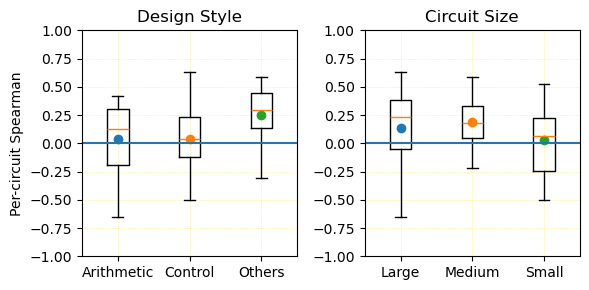

[INFO] Saved combined robustness plot as robustness_style_and_size.pdf


In [15]:
# CELL: Side-by-side robustness plots (Design Style + Circuit Size)
# Saved as ONE combined PDF

import numpy as np
import matplotlib.pyplot as plt

# Ensure 'records' exists from previous computation
# records contains: style, size_tag, spearman

# ----------------------------
# 1) Group data
# ----------------------------
def group_values(records, key):
    groups = {}
    for r in records:
        k = r[key]
        v = r["spearman"]
        if np.isnan(v):
            continue
        groups.setdefault(k, []).append(v)
    return groups

style_groups = group_values(records, "style")
size_groups  = group_values(records, "size_tag")

# Sort keys for consistent ordering
style_labels = sorted(style_groups.keys())
size_labels  = sorted(size_groups.keys())

style_data = [style_groups[k] for k in style_labels]
size_data  = [size_groups[k]  for k in size_labels]

# ----------------------------
# 2) Create side-by-side figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# ----- Left: Design Style -----
axes[0].boxplot(style_data, labels=style_labels)
for i, vals in enumerate(style_data):
    axes[0].plot(i+1, np.mean(vals), marker='o')

axes[0].axhline(0.0)
axes[0].set_title("Design Style")
axes[0].set_ylabel("Per-circuit Spearman")
axes[0].set_ylim(-1.0, 1.0)
axes[0].set_xticklabels(['Arithmetic','Control','Others'])
axes[0].grid(True, 
         linestyle=':', 
         linewidth=0.4, 
         color='#FFD700',  # Gold color
         alpha=0.8)        # Slight transparency

# ----- Right: Circuit Size -----
axes[1].boxplot(size_data, labels=size_labels)
for i, vals in enumerate(size_data):
    axes[1].plot(i+1, np.mean(vals), marker='o')

axes[1].axhline(0.0)
axes[1].set_title("Circuit Size")
axes[1].set_ylim(-1.0, 1.0)
axes[1].set_xticklabels(['Large','Medium','Small'])
axes[1].grid(True, 
         linestyle=':', 
         linewidth=0.4, 
         color='#FFD700',  # Gold color
         alpha=0.8)        # Slight transparency
plt.tight_layout()

# ----------------------------
# 3) Save as single PDF
# ----------------------------
plt.savefig("robustness_style_and_size.pdf", bbox_inches="tight")
plt.savefig("robustness_style_and_size.png", dpi=300, bbox_inches="tight")

plt.show()

print("[INFO] Saved combined robustness plot as robustness_style_and_size.pdf")

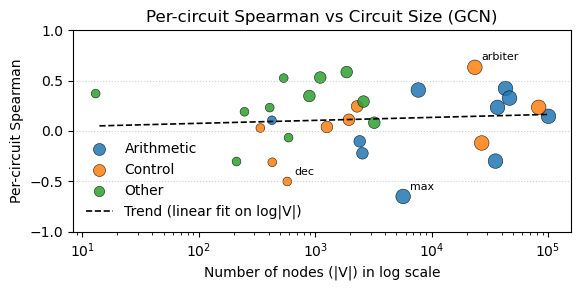

[INFO] Saved plot as spearman_vs_size.pdf


In [29]:
# Clean single plot: Spearman vs Circuit Size (trend + style + outliers)

import numpy as np
import matplotlib.pyplot as plt

# --- prepare arrays from `records` ---
names  = np.array([r['circuit'] for r in records])
sizes  = np.array([r['nodes'] for r in records], dtype=float)
spr    = np.array([r['spearman'] for r in records], dtype=float)
styles = np.array([r['style'] for r in records])
size_tag = np.array([r['size_tag'] for r in records])

# Style colors
style_order = ['arith', 'control', 'other']
style_colors = {'arith':'#1f77b4', 'control':'#ff7f0e', 'other':'#2ca02c'}

# Marker size by size_tag
size_map = {'small':40, 'medium':70, 'large':110}

# --- Fit linear trend: Spearman ~ log(|V|)
logx = np.log10(sizes + 1.0)
mask = np.isfinite(spr) & np.isfinite(logx)
coeff = np.polyfit(logx[mask], spr[mask], 1)
poly = np.poly1d(coeff)

xx_line = np.linspace(logx.min(), logx.max(), 200)
yy_line = poly(xx_line)

# --- Identify top 3 outliers (largest residuals)
preds = poly(logx)
resid = np.abs(spr - preds)
outlier_idx = np.argsort(resid)[-3:]

# --- Plot ---
plt.figure(figsize=(6,3))

for s in style_order:
    sel = styles == s
    plt.scatter(
        sizes[sel],
        spr[sel],
        s=np.array([size_map[z] for z in size_tag[sel]]),
        c=style_colors[s],
        label=s.capitalize(),
        alpha=0.85,
        edgecolors='k',
        linewidth=0.4
    )

# Trend line
plt.plot(10**xx_line, yy_line, linestyle='--', linewidth=1.2, color='black',
         label='Trend (linear fit on log|V|)')

# Annotate top 3 outliers
for i in outlier_idx:
    plt.annotate(
        names[i].replace('.v',''),
        (sizes[i], spr[i]),
        xytext=(5,5),
        textcoords='offset points',
        fontsize=8
    )

plt.xscale('log')
plt.xlabel('Number of nodes (|V|) in log scale')
plt.ylabel('Per-circuit Spearman')
plt.title('Per-circuit Spearman vs Circuit Size (GCN)')
plt.ylim(-1.0, 1.0)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(frameon=False)
legend = plt.legend(frameon=False)
legend.get_texts()[0].set_text('Arithmetic')

plt.tight_layout()
plt.savefig("spearman_vs_size.pdf", bbox_inches='tight')
plt.savefig("spearman_vs_size.png", dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Saved plot as spearman_vs_size.pdf")

#### M(v) intermediate result calculations.

In [36]:
import torch
import networkx as nx
import numpy as np
from scipy.stats import spearmanr

DATA_PATH = "gnn_structural_netlist_dataset.pt"  # adjust if needed

# -------------------------
# 1) Load dataset
# -------------------------
obj = torch.load(DATA_PATH, map_location="cpu")
if isinstance(obj, dict) and "data_list" in obj:
    data_list = obj["data_list"]
else:
    data_list = obj  # assuming it's already a list

print(f"[INFO] Loaded {len(data_list)} circuits from {DATA_PATH}")

# -------------------------
# 2) Keep only the first 23 circuits (as per your progress log)
# -------------------------
MAX_CIRCUITS = 22
data_list = data_list[:MAX_CIRCUITS]
print(f"[INFO] Limiting analysis to first {len(data_list)} circuits to avoid very large designs.")

# -------------------------
# 3) Helper: build DiGraph from a PyG Data
# -------------------------
def data_to_digraph(data):
    G = nx.DiGraph()
    edge_index = data.edge_index.numpy()
    num_nodes = data.num_nodes

    G.add_nodes_from(range(num_nodes))

    x = getattr(data, "x", None)
    if x is not None:
        for i in range(num_nodes):
            G.nodes[i]["feat"] = x[i].numpy()

    for u, v in edge_index.T:
        G.add_edge(int(u), int(v))
    return G

# -------------------------
# 4) WL-style symmetry hashing
# -------------------------
def wl_hash_labels(G, num_iter=2):
    labels = {}
    for n in G.nodes():
        feat = G.nodes[n].get("feat", None)
        if feat is not None:
            labels[n] = int(np.argmax(feat))
        else:
            labels[n] = G.degree[n]

    for _ in range(num_iter):
        new_labels = {}
        label_counter = {}
        next_id = 0

        for n in G.nodes():
            neigh_labels = sorted(labels[nb] for nb in G.neighbors(n))
            key = (labels[n], tuple(neigh_labels))
            if key not in label_counter:
                label_counter[key] = next_id
                next_id += 1
            new_labels[n] = label_counter[key]
        labels = new_labels

    return labels

# -------------------------
# 5) Component computation across selected circuits
# -------------------------

# weights (change if your paper uses different ones)
ALPHA = 0.25  # path
BETA  = 0.25  # core
GAMMA = 0.25  # sym
DELTA = 0.25  # cent

all_M_path = []
all_M_core = []
all_M_sym  = []
all_M_cent = []
all_M_full = []

for idx, data in enumerate(data_list):
    cname = getattr(data, "circuit_name", f"circuit_{idx}")
    print(f"[{idx+1:02d}/{len(data_list):02d}] Processing {cname} ...")

    G = data_to_digraph(data)
    n = G.number_of_nodes()
    if n == 0:
        continue

    nodes = list(G.nodes())

    # --- core numbers ---
    core_nums = nx.core_number(G)
    max_core = max(core_nums.values()) if core_nums else 1
    M_core = np.array([core_nums[v] / max_core for v in nodes], dtype=np.float32)

    # --- symmetry term (WL class size / n) ---
    wl_labels = wl_hash_labels(G, num_iter=2)
    class_count = {}
    for v in nodes:
        lab = wl_labels[v]
        class_count[lab] = class_count.get(lab, 0) + 1
    M_sym = np.array([class_count[wl_labels[v]] / float(n) for v in nodes], dtype=np.float32)

    # --- approximate betweenness (path participation proxy) ---
    # keep sampling small to avoid stalls
    k_sample = min(64, n)
    betw = nx.betweenness_centrality(G, k=k_sample, normalized=True, seed=0)
    b_vals = np.array([betw[v] for v in nodes], dtype=np.float32)
    M_path = 1.0 - b_vals

    # --- centrality term (closeness flipped, normalized) ---
    closeness = nx.closeness_centrality(G)
    c_vals = np.array([closeness[v] for v in nodes], dtype=np.float32)
    c_norm = c_vals / c_vals.max() if c_vals.max() > 0 else c_vals
    M_cent = 1.0 - c_norm

    # --- composite ---
    M_full = (ALPHA * M_path +
              BETA  * M_core +
              GAMMA * M_sym  +
              DELTA * M_cent)

    all_M_path.append(M_path)
    all_M_core.append(M_core)
    all_M_sym.append(M_sym)
    all_M_cent.append(M_cent)
    all_M_full.append(M_full)

# concatenate
M_path_all = np.concatenate(all_M_path, axis=0)
M_core_all = np.concatenate(all_M_core, axis=0)
M_sym_all  = np.concatenate(all_M_sym,  axis=0)
M_cent_all = np.concatenate(all_M_cent, axis=0)
M_full_all = np.concatenate(all_M_full, axis=0)

print("\n================ Component stats vs composite M(v) (first 23 circuits) ================")
components = {"path": M_path_all, "core": M_core_all, "sym": M_sym_all, "cent": M_cent_all}

for name, comp in components.items():
    mu  = float(comp.mean())
    std = float(comp.std())
    rho, _ = spearmanr(comp, M_full_all)
    print(f"{name:>6} | mean={mu:.3f} std={std:.3f} | Spearman(M_{name}, M)={rho:.3f}")

/tmp/ipykernel_121240/3497017497.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(DATA_PATH, map_location="cpu")


[INFO] Loaded 30 circuits from gnn_structural_netlist_dataset.pt
[INFO] Limiting analysis to first 22 circuits to avoid very large designs.
[01/22] Processing c17.v ...
[02/22] Processing c432.v ...
[03/22] Processing c499.v ...
[04/22] Processing ctrl.v ...
[05/22] Processing c880.v ...
[06/22] Processing int2float.v ...
[07/22] Processing router.v ...
[08/22] Processing c1908.v ...
[09/22] Processing c1355.v ...
[10/22] Processing dec.v ...
[11/22] Processing c2670.v ...
[12/22] Processing c3540.v ...
[13/22] Processing cavlc.v ...
[14/22] Processing Priority.v ...
[15/22] Processing c5315.v ...
[16/22] Processing i2c.v ...
[17/22] Processing adder.v ...
[18/22] Processing c6288.v ...
[19/22] Processing c7552.v ...
[20/22] Processing bar.v ...
[21/22] Processing max.v ...
[22/22] Processing sin.v ...

================ Component stats vs composite M(v) (first 23 circuits) ================
  path | mean=0.992 std=0.044 | Spearman(M_path, M)=0.144
  core | mean=0.848 std=0.193 | Spearma